In [1]:
# Imports

import os
import sys
import rdkit
import joblib
import logging
import warnings
import subprocess
import numpy as np
import pandas as pd
import deepchem as dc
from time import sleep
from scipy import stats
import pubchempy as pcp
from pathlib import Path
from tqdm.auto import tqdm
from typing import Optional
from __future__ import division
import matplotlib.pyplot as plt
from collections import Counter
from xgboost import XGBClassifier
from IPython.display import display
from pandarallel import pandarallel
from __future__ import absolute_import
from __future__ import unicode_literals
from rdkit.Chem.Draw import IPythonConsole
from deepchem.splits import ButinaSplitter
from dimorphite_dl import protonate_smiles
from rdkit.Chem.EState import Fingerprinter
from mordred import Calculator, descriptors
from rdkit.DataStructs import BitVectToText
from rdkit.Chem.MACCSkeys import GenMACCSKeys
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from rdkit.ML.Descriptors import MoleculeDescriptors 
from sklearn.model_selection import train_test_split
from rdkit import Chem, DataStructs, rdBase, RDLogger
from rdkit.Chem.MolStandardize import rdMolStandardize
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from rdkit.Chem import AllChem, Draw, Descriptors, PandasTools, AddHs, inchi, MolStandardize
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Suppress warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore")
RDLogger.DisableLog('rdApp.*')

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
/Users/HQ/miniforge3/envs/DILI/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with transformers dependency. No module named 'transformers.models.roberta.tokenization_roberta_fast'
cannot import name 'Chemberta' from 'deepchem.models.torch_models' (/Users/HQ/miniforge3/envs/DILI/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading some Jax models, missing a dependency. No module named 'haiku'


In [46]:
# Define data

root_dir = '/Users/HQ/Repositories/DILI/'
data_dir = os.path.join(root_dir, 'Data')

dili_rank_2 = os.path.join(data_dir, 'DILIrank-2.0.csv')
dili_rank_2 = pd.read_csv(dili_rank_2, header=1)

mapping = {
    'vMost-DILI-concern': 'Most',
    'vMOST-DILI-concern': 'Most',
    'vLess-DILI-concern': 'Less',
    'vNo-DILI-concern':   'No',
    'vNo-DILI-Concern':   'No',
    'Ambiguous-DILI-concern': 'Ambiguous'
}

dili_rank_2['Label'] = dili_rank_2['Concern'].replace(mapping)
dili_rank_2 = dili_rank_2[dili_rank_2['Label'].isin(['Most', 'Less', 'No'])].copy()


features = pd.read_csv(f'{data_dir}/DILI_rank_2_features.csv')

In [43]:
# Get SMILES from PubChem

def get_smiles_from_name(compound_name: str, max_retries: int = 3, sleep_time: float = 0.5) -> Optional[str]:
    """
    Returns the canonical SMILES for a compound name using PubChem.
    Handles common salts (e.g., hydrochloride, sulfate) automatically.
    
    Returns None if no structure is found or on error.
    """
    name = compound_name.strip()
    
    for attempt in range(max_retries):
        try:
            results = pcp.get_compounds(name, namespace='name', timeout=10)
            if results:
                return results[0].connectivity_smiles
            # If no hit, try a slightly cleaned version (sometimes helps)
            if attempt == 0 and ("hydrochloride" in name.lower() or 
                                 "sulfate" in name.lower() or 
                                 "maleate" in name.lower()):
                name = name.split()[0]  # try parent name
                continue
                
        except Exception:
            sleep(sleep_time)  # respect PubChem rate limit
            continue
            
    return None  # Not found after retries

tqdm.pandas()
dili_rank_2["smiles_r"] = dili_rank_2["CompoundName"].progress_apply(get_smiles_from_name)

  0%|          | 0/982 [00:00<?, ?it/s]

In [87]:
# Check for invalid entries

# Initialize counters for each criterion
counters = {
    'invalid_smiles': 0,
    'no_carbon': 0,
    'is_mixture': 0,
    'contains_metals': 0,
    'above_mw_threshold': 0
}

# Function to check exclusion criteria and update counters
def check_criteria(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles) 
        if mol is None:
            counters['invalid_smiles'] += 1
            return False
        if not mol.HasSubstructMatch(Chem.MolFromSmarts('C')):
            counters['no_carbon'] += 1
            return False
        # if mol.GetNumAtoms() != Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=False)[0].GetNumAtoms():
        #     counters['is_mixture'] += 1
        #     return False
        if any(atom.GetSymbol().isupper() and atom.GetSymbol() not in ['C', 'H', 'N', 'O', 'P', 'S', 'F', 'Cl', 'Br', 'I'] for atom in mol.GetAtoms()):
            counters['contains_metals'] += 1
            return False
        if Descriptors.MolWt(mol) > 1500:
            counters['above_mw_threshold'] += 1
            return False
        return True
    except:
        counters['invalid_smiles'] += 1
        return False

# Apply the criteria checking function to each SMILES string
dili_rank_2['include'] = dili_rank_2['smiles_r'].apply(check_criteria)

# Filter the DataFrame to include only the molecules that passed all criteria
valid_dili_rank_2 = dili_rank_2[dili_rank_2['include']].reset_index(drop=True)

# Now, print the counters to see how many compounds were excluded for each reason
for criterion, count in counters.items():
    print(f"{criterion}: {count}")

# The result is 'valid_tox_data' which contains only the molecules meeting the criteria
# You can now drop the 'include' column if you want
valid_dili_rank_2 = valid_dili_rank_2.drop(columns=['include'])

invalid_smiles: 90
no_carbon: 25
is_mixture: 0
contains_metals: 5
above_mw_threshold: 22


In [88]:
# Standardize Entries with RDKit

def standardize_jumpcp(smiles):
    
    # Read SMILES and convert it to RDKit mol object
    mol = Chem.MolFromSmiles(smiles)
 
    smiles_clean_counter = Counter()
    mol_dict = {}
    is_finalize = False

    try:
        for _ in range(5):

            mol = Chem.MolFromSmiles(smiles)
            inchi_standardised = Chem.MolToInchi(mol)
            inchi_standardised
            mol = Chem.MolFromInchi(inchi_standardised)
            mol = rdMolStandardize.Cleanup(mol) 
            mol = rdMolStandardize.FragmentParent(mol) # if many fragments, get the "parent" (the actual mol we are interested in) 
            uncharger = rdMolStandardize.Uncharger()

            mol = uncharger.uncharge(mol) # standardize molecules using MolVS and RDKit
            mol = rdMolStandardize.ChargeParent(mol)
            mol = rdMolStandardize.IsotopeParent(mol)
            mol = rdMolStandardize.StereoParent(mol)

            # Normalize tautomers 
            # Method 1
            normalizer = rdMolStandardize.TautomerEnumerator()
            mol = normalizer.Canonicalize(mol)

            # Method 2
            te = rdMolStandardize.TautomerEnumerator() # idem
            mol = te.Canonicalize(mol)

            # Method 3
            mol = rdMolStandardize.TautomerParent(mol)

            # Final Rules
            mol = rdMolStandardize.Normalize(mol)
            mol_standardized = mol

            # Convert mol object back to SMILES
            smiles_standardized = Chem.MolToSmiles(mol_standardized)

            if smiles == smiles_standardized:
                is_finalize = True
                break

            smiles_clean_counter[smiles_standardized] += 1
            if smiles_standardized not in mol_dict:
                mol_dict[smiles_standardized] = mol_standardized

            smiles = smiles_standardized
            mol = Chem.MolFromSmiles(smiles)

        if not is_finalize:
            # If the standardization process is not finalized, we choose the most common SMILES from the counter and the corresponding mol object
            smiles_standardized = smiles_clean_counter.most_common()[0][0]
            mol_standardized = mol_dict[smiles_standardized]
            
        return smiles_standardized
    except Exception as e:
        print(f'{smiles}: {e}')
        return 'INVALID'

tqdm.pandas()
pandarallel.initialize(progress_bar=True)
valid_dili_rank_2["smiles_r"] = valid_dili_rank_2["smiles_r"].parallel_apply(standardize_jumpcp)
valid_dili_rank_2_file = os.path.join(data_dir, 'valid_dili_rank_2.csv')
valid_dili_rank_2.to_csv(valid_dili_rank_2_file)

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [89]:
# Protonate entries with DimorphiteDL and deduplicate

def protonate(smiles):

    protonated_smiles = protonate_smiles(
    smiles,
    ph_min=7.0,
    ph_max=7.0,
    precision=0,
    max_variants=1
)
    if len(protonated_smiles) > 0:
                protonated_smiles = protonated_smiles[0]
    return protonated_smiles
    
def smiles_to_inchikey(smiles):

    try:
        mol = Chem.MolFromSmiles(smiles)
        inchi_string = Chem.MolToInchi(mol)
        inchi_key = Chem.inchi.InchiToInchiKey(inchi_string)
        return inchi_key
    
    except Exception as e:
        print(f'{smiles}: {e}')
        return "INVALID"

valid_dili_rank_2['InChIKey'] = valid_dili_rank_2["smiles_r"].parallel_apply(smiles_to_inchikey)
valid_dili_rank_2['InChIKey14'] = valid_dili_rank_2["InChIKey"].str[:14]
valid_dili_rank_2['protonated_smiles_r'] = valid_dili_rank_2["smiles_r"].parallel_apply(protonate)

valid_dili_rank_2 = valid_dili_rank_2.drop_duplicates(subset='InChIKey14', keep='first')
# Group entries by source and deduplicate

# Display or return the processed DataFrame
valid_dili_rank_2 = valid_dili_rank_2[valid_dili_rank_2["smiles_r"]!="INVALID"]
valid_dili_rank_2 = valid_dili_rank_2[valid_dili_rank_2["InChIKey"]!="INVALID"]
valid_dili_rank_2 = valid_dili_rank_2[valid_dili_rank_2["protonated_smiles_r"]!="INVALID"]


In [90]:
# Generate Morgan Fingerprints

def MorganFingerprint(s):
    x = Chem.MolFromSmiles(s)
    return (AllChem.GetMorganFingerprintAsBitVect(x,2,2048))

MorganFingerprint_array = np.stack(valid_dili_rank_2['protonated_smiles_r'].apply(MorganFingerprint))

Morgan_fingerprint_collection = []
for x in np.arange(MorganFingerprint_array.shape[1]):
    x = "Mfp"+str(x)
    Morgan_fingerprint_collection.append(x)

Morgan_fingerprint_table = pd.DataFrame(MorganFingerprint_array, columns=Morgan_fingerprint_collection)

In [98]:
# Generate MACCS Keys

def MACCSKeysFingerprint(s):
    x = Chem.MolFromSmiles(s)
    return (AllChem.GetMACCSKeysFingerprint(x))

MACCSfingerprint_array = np.stack(valid_dili_rank_2['protonated_smiles_r'].apply(MACCSKeysFingerprint))

MACCS_collection = []
for x in np.arange(MACCSfingerprint_array.shape[1]):
    x = "MACCS"+str(x)
    MACCS_collection.append(x)

MACCSfingerprint_table = pd.DataFrame(MACCSfingerprint_array, columns=MACCS_collection)
MACCSfingerprint_table = MACCSfingerprint_table.drop(['MACCS0'], axis=1)

In [92]:
# Generate Mordred Table

calc = Calculator(descriptors, ignore_3D=True)

print(len(calc.descriptors))

Ser_Mol = valid_dili_rank_2['protonated_smiles_r'].apply(Chem.MolFromSmiles)
Mordred_table = calc.pandas(Ser_Mol)
Mordred_table = Mordred_table.astype('float')

Mordred_table_file = os.path.join(data_dir, 'DILIRank-2.0_Mordred_table.csv')
Mordred_table.to_csv(Mordred_table_file)

Mordred_table = Mordred_table.dropna(axis='columns')

1613


  7%|▋         | 55/818 [00:01<00:13, 55.21it/s]

/Users/HQ/miniforge3/envs/dili/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/HQ/miniforge3/envs/dili/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/HQ/miniforge3/envs/dili/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  8%|▊         | 65/818 [00:01<00:13, 56.62it/s]

/Users/HQ/miniforge3/envs/dili/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/HQ/miniforge3/envs/dili/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/HQ/miniforge3/envs/dili/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


...

 23%|██▎       | 188/818 [00:03<00:13, 46.81it/s] 

/Users/HQ/miniforge3/envs/dili/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 44%|████▍     | 361/818 [00:05<00:08, 55.84it/s]

/Users/HQ/miniforge3/envs/dili/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 818/818 [00:12<00:00, 67.64it/s] 


In [93]:
# Generate 2D descriptors

def get_num_charged_atoms_neg(mol):
    mol_h = Chem.AddHs(mol)
    Chem.rdPartialCharges.ComputeGasteigerCharges(mol_h)
     
    positive = 0
    negative = 0
     
    for atom in mol_h.GetAtoms():
        if float(atom.GetProp('_GasteigerCharge')) <= 0:
            negative += 1
     
    return negative

def get_num_charged_atoms_pos(mol):
    mol_h = Chem.AddHs(mol)
    Chem.rdPartialCharges.ComputeGasteigerCharges(mol_h)
     
    positive = 0
    negative = 0
     
    for atom in mol_h.GetAtoms():
        if float(atom.GetProp('_GasteigerCharge')) >= 0:
            positive += 1
    return positive

def get_assembled_ring(mol):
    ring_info = mol.GetRingInfo()
    num_ring = ring_info.NumRings()
    ring_atoms = ring_info.AtomRings()
    num_assembled = 0
     
    for i in range(num_ring):
        for j in range(i+1, num_ring):
            x = set(ring_atoms[i])
            y = set(ring_atoms[j])
            if not x.intersection(y): # 2つの環が縮環でない場合に
                for x_id in x:
                    x_atom = mol.GetAtomWithIdx(x_id)
                    neighbors = [k.GetIdx() for k in x_atom.GetNeighbors()]
                    for x_n in neighbors:
                        if x_n in y: # 環同士を繋ぐ結合があるか否か
                            num_assembled += 1
     
    return num_assembled

def get_num_stereocenters(mol):
    return AllChem.CalcNumAtomStereoCenters(mol) + AllChem.CalcNumUnspecifiedAtomStereoCenters(mol)

def calc_descriptors(dataframe):
    mols = dataframe.protonated_smiles_r.apply(Chem.MolFromSmiles)
    descr = []
    for m in mols:
        descr.append([ Descriptors.TPSA(m),
               Descriptors.NumRotatableBonds(m),
               AllChem.CalcNumRings(m),
               Descriptors.NumAromaticRings(m),
               Descriptors.NumHAcceptors(m),
               Descriptors.NumHDonors(m),
               Descriptors.FractionCSP3(m),
               Descriptors.MolLogP(m) ,
               Descriptors.NHOHCount(m),
               Descriptors.NOCount(m),
               Descriptors.NumHeteroatoms(m),
               get_num_charged_atoms_pos(m),
               get_num_charged_atoms_neg(m),
               get_assembled_ring(m),
               get_num_stereocenters(m)])
    descr = np.asarray(descr)
    return(descr)

descs = [ 'PSA', 'n_rot_bonds', 'n_rings', 'n_ar_rings',
         'n_HBA', 'n_HBD', 'Fsp3', 'logP', 'NHOHCount', 'NOCount', 'NumHeteroatoms',
        'n_positive', '_n_negative', 'n_ring_asmbl', 'n_stereo']
a=calc_descriptors(valid_dili_rank_2)
descdf=pd.DataFrame(a, columns=descs)
descdf_approved=descdf.reset_index(drop=True)

In [ ]:
# Filter by Variance and Combine

vt_morgan = VarianceThreshold(threshold=0.05)
morgan_sel = vt_morgan.fit_transform(Morgan_fingerprint_table)
morgan_sel = pd.DataFrame(
    morgan_sel,
    columns=Morgan_fingerprint_table.columns[vt_morgan.get_support()]
)

# MACCS filtering (threshold 0.10)
vt_maccs = VarianceThreshold(threshold=0.10)
maccs_sel = vt_maccs.fit_transform(MACCSfingerprint_table)
maccs_sel = pd.DataFrame(
    maccs_sel,
    columns=MACCSfingerprint_table.columns[vt_maccs.get_support()]
)

# Mordred + desc2D filtering (threshold 0.10)
vt_mrdrd = VarianceThreshold(threshold=0.10)
mordred_sel = vt_mrdrd.fit_transform(Mordred_table)
mordred_sel = pd.DataFrame(
    mordred_sel,
    columns=Mordred_table.columns[vt_mrdrd.get_support()]
)

X_filtered = pd.concat([morgan_sel, maccs_sel, mordred_sel], axis=1)

variances = X_filtered.var().sort_values(ascending=False)
top_842_cols = variances.head(842).index

X_for_proxy = X_filtered[top_842_cols].copy()

X_filtered = pd.concat([X_for_proxy, descdf_approved], axis=1)

X_filtered.shape

DILI_rank_2_features_file  = os.path.join(data_dir, 'DILI_rank_2_features_filtered.csv')
X_filtered.to_csv(DILI_rank_2_features_file, index=False)

variances = X_filtered.var()
lowest_var_column = variances.idxmin()

In [135]:
# Combine Features

features = pd.concat([valid_dili_rank_2.reset_index(drop=True), Morgan_fingerprint_table.reset_index(drop=True), MACCSfingerprint_table.reset_index(drop=True), descdf_approved.reset_index(drop=True), Mordred_table.reset_index(drop=True)], axis=1)
features = features.drop(['LTKBID', 'SeverityClass', 'LabelSection', 'Concern', 'Comment', 'Unnamed: 6'], axis=1)
DILI_rank_2_features_file  = os.path.join(data_dir, 'DILI_rank_2_features.csv')
features.to_csv(DILI_rank_2_features_file, index=False)

In [24]:
# Define models

MODEL_PATH = Path("/Users/HQ/Repositories/PredictorDILI/Local_Implementation_v4/models")   # ← change if you put it elsewhere

# Load all 11 proxy models
model_files = {
    "bestlivmodel_3_model.sav":  "human_hepatotoxicity",
    "bestlivmodel_5_model.sav":  "animal_hepatotoxicity_A",
    "bestlivmodel_6_model.sav":  "animal_hepatotoxicity_B",
    "bestlivmodel_7_model.sav":  "preclinical_hepatotoxicity",
    "bestlivmodel_8_model.sav":  "diverse_DILI_A",
    "bestlivmodel_10_model.sav": "diverse_DILI_C",
    "bestlivmodel_11_model.sav": "BSEP_inhibition",
    "bestlivmodel_14_model.sav": "mitochondrial_toxicity",
    "bestlivmodel_15_model.sav": "reactive_metabolite",
    
    # The two regression models
    "bestlivmodel_median pMolar total plasma concentration_model.sav":   "Cmax_total",
    "bestlivmodel_median pMolar unbound plasma concentration_model.sav": "Cmax_unbound",
}

# Load all models
proxy_models = {}
for filename, name in model_files.items():
    path = MODEL_PATH / filename
    if path.exists():
        proxy_models[name] = joblib.load(path)

for name, model in proxy_models.items():
    try:
        n = model.n_features_in_
        print(f"{name:30} → {n} features")
    except:
        print(f"{name:30} → UNKNOWN")

# # print(f"\nSuccessfully loaded {len(proxy_models)} proxy models")

human_hepatotoxicity           → 857 features
animal_hepatotoxicity_A        → 857 features
animal_hepatotoxicity_B        → 857 features
preclinical_hepatotoxicity     → 857 features
diverse_DILI_A                 → 857 features
diverse_DILI_C                 → 856 features
BSEP_inhibition                → 857 features
mitochondrial_toxicity         → 857 features
reactive_metabolite            → 857 features
Cmax_total                     → 857 features
Cmax_unbound                   → 857 features


In [57]:
# Get which feature columns are reqeusted by each model

expected_columns = ['ABC', 'ABCGG', 'nAcid', 'nBase', 'SpAbs_A', 'SpDiam_A', 'SpAD_A', 'LogEE_A', 'VE1_A', 'VE3_A', 'VR1_A', 'VR2_A', 'nAromAtom', 'nAromBond', 'nAtom', 'nHeavyAtom', 'nBridgehead', 'nHetero', 'nH', 'nC', 'nN', 'nO', 'nS', 'nF', 'nCl', 'nX', 'ATS0dv', 'ATS1dv', 'ATS2dv', 'ATS3dv', 'ATS4dv', 'ATS5dv', 'ATS6dv', 'ATS7dv', 'ATS8dv', 'ATS0d', 'ATS1d', 'ATS2d', 'ATS3d', 'ATS4d', 'ATS5d', 'ATS6d', 'ATS7d', 'ATS8d', 'ATS0Z', 'ATS1Z', 'ATS2Z', 'ATS3Z', 'ATS4Z', 'ATS5Z', 'ATS6Z', 'ATS7Z', 'ATS8Z', 'ATS0m', 'ATS1m', 'ATS2m', 'ATS3m', 'ATS4m', 'ATS5m', 'ATS6m', 'ATS7m', 'ATS8m', 'ATS0v', 'ATS1v', 'ATS2v', 'ATS3v', 'ATS4v', 'ATS5v', 'ATS6v', 'ATS7v', 'ATS8v', 'ATS0se', 'ATS1se', 'ATS2se', 'ATS3se', 'ATS4se', 'ATS5se', 'ATS6se', 'ATS7se', 'ATS8se', 'ATS0pe', 'ATS1pe', 'ATS2pe', 'ATS3pe', 'ATS4pe', 'ATS5pe', 'ATS6pe', 'ATS7pe', 'ATS8pe', 'ATS0are', 'ATS1are', 'ATS2are', 'ATS3are', 'ATS4are', 'ATS5are', 'ATS6are', 'ATS7are', 'ATS8are', 'ATS0p', 'ATS1p', 'ATS2p', 'ATS3p', 'ATS4p', 'ATS5p', 'ATS6p', 'ATS7p', 'ATS8p', 'ATS0i', 'ATS1i', 'ATS2i', 'ATS3i', 'ATS4i', 'ATS5i', 'ATS6i', 'ATS7i', 'ATS8i', 'AATS0dv', 'AATS1dv', 'AATS0d', 'AATS1d', 'AATS0Z', 'AATS1Z', 'AATS0m', 'AATS1m', 'AATS0v', 'AATS1v', 'AATS0se', 'AATS1se', 'AATS0pe', 'AATS1pe', 'AATS0are', 'AATS1are', 'AATS0p', 'AATS0i', 'AATS1i', 'ATSC0dv', 'ATSC1dv', 'ATSC2dv', 'ATSC3dv', 'ATSC4dv', 'ATSC5dv', 'ATSC6dv', 'ATSC7dv', 'ATSC8dv', 'ATSC0d', 'ATSC1d', 'ATSC2d', 'ATSC3d', 'ATSC4d', 'ATSC5d', 'ATSC6d', 'ATSC7d', 'ATSC8d', 'ATSC0Z', 'ATSC1Z', 'ATSC2Z', 'ATSC3Z', 'ATSC4Z', 'ATSC5Z', 'ATSC6Z', 'ATSC7Z', 'ATSC8Z', 'ATSC0m', 'ATSC1m', 'ATSC2m', 'ATSC3m', 'ATSC4m', 'ATSC5m', 'ATSC6m', 'ATSC7m', 'ATSC8m', 'ATSC0v', 'ATSC1v', 'ATSC2v', 'ATSC3v', 'ATSC4v', 'ATSC5v', 'ATSC6v', 'ATSC7v', 'ATSC8v', 'ATSC0se', 'ATSC1se', 'ATSC2se', 'ATSC3se', 'ATSC4se', 'ATSC5se', 'ATSC6se', 'ATSC7se', 'ATSC8se', 'ATSC0pe', 'ATSC1pe', 'ATSC2pe', 'ATSC3pe', 'ATSC4pe', 'ATSC5pe', 'ATSC6pe', 'ATSC7pe', 'ATSC8pe', 'ATSC0are', 'ATSC1are', 'ATSC2are', 'ATSC3are', 'ATSC4are', 'ATSC5are', 'ATSC6are', 'ATSC7are', 'ATSC8are', 'ATSC0p', 'ATSC1p', 'ATSC2p', 'ATSC3p', 'ATSC4p', 'ATSC5p', 'ATSC6p', 'ATSC7p', 'ATSC8p', 'ATSC0i', 'ATSC1i', 'ATSC2i', 'ATSC3i', 'ATSC4i', 'ATSC5i', 'ATSC6i', 'ATSC7i', 'ATSC8i', 'AATSC0dv', 'AATSC1dv', 'AATSC0Z', 'AATSC1Z', 'AATSC0m', 'AATSC1m', 'AATSC0v', 'AATSC1v', 'AATSC0i', 'BCUTdv-1h', 'BCUTdv-1l', 'BCUTd-1h', 'BCUTZ-1h', 'BCUTm-1h', 'BCUTv-1h', 'BCUTv-1l', 'BCUTp-1h', 'BCUTi-1h', 'BalabanJ', 'SpAbs_DzZ', 'SpMax_DzZ', 'SpDiam_DzZ', 'SpAD_DzZ', 'SpMAD_DzZ', 'LogEE_DzZ', 'SM1_DzZ', 'VE1_DzZ', 'VE3_DzZ', 'VR1_DzZ', 'VR2_DzZ', 'SpAbs_Dzm', 'SpMax_Dzm', 'SpDiam_Dzm', 'SpAD_Dzm', 'SpMAD_Dzm', 'LogEE_Dzm', 'SM1_Dzm', 'VE1_Dzm', 'VE3_Dzm', 'VR1_Dzm', 'VR2_Dzm', 'SpAbs_Dzv', 'SpMax_Dzv', 'SpDiam_Dzv', 'SpAD_Dzv', 'SpMAD_Dzv', 'LogEE_Dzv', 'SM1_Dzv', 'VE1_Dzv', 'VE3_Dzv', 'VR1_Dzv', 'VR2_Dzv', 'SpAbs_Dzse', 'SpMax_Dzse', 'SpDiam_Dzse', 'SpAD_Dzse', 'SpMAD_Dzse', 'LogEE_Dzse', 'SM1_Dzse', 'VE1_Dzse', 'VE3_Dzse', 'VR1_Dzse', 'VR2_Dzse', 'SpAbs_Dzpe', 'SpMax_Dzpe', 'SpDiam_Dzpe', 'SpAD_Dzpe', 'SpMAD_Dzpe', 'LogEE_Dzpe', 'SM1_Dzpe', 'VE1_Dzpe', 'VE3_Dzpe', 'VR1_Dzpe', 'VR2_Dzpe', 'SpAbs_Dzare', 'SpMax_Dzare', 'SpDiam_Dzare', 'SpAD_Dzare', 'SpMAD_Dzare', 'LogEE_Dzare', 'SM1_Dzare', 'VE1_Dzare', 'VE3_Dzare', 'VR1_Dzare', 'VR2_Dzare', 'SpAbs_Dzp', 'SpMax_Dzp', 'SpDiam_Dzp', 'SpAD_Dzp', 'SpMAD_Dzp', 'LogEE_Dzp', 'SM1_Dzp', 'VE1_Dzp', 'VE3_Dzp', 'VR1_Dzp', 'VR2_Dzp', 'SpAbs_Dzi', 'SpMax_Dzi', 'SpDiam_Dzi', 'SpAD_Dzi', 'SpMAD_Dzi', 'LogEE_Dzi', 'SM1_Dzi', 'VE1_Dzi', 'VE3_Dzi', 'VR1_Dzi', 'VR2_Dzi', 'BertzCT', 'nBonds', 'nBondsO', 'nBondsS', 'nBondsD', 'nBondsA', 'nBondsM', 'nBondsKS', 'nBondsKD', 'C1SP2', 'C2SP2', 'C3SP2', 'C1SP3', 'C2SP3', 'C3SP3', 'C4SP3', 'Xch-7d', 'Xch-7dv', 'Xc-3d', 'Xc-5d', 'Xc-6d', 'Xc-3dv', 'Xc-5dv', 'Xpc-4d', 'Xpc-5d', 'Xpc-6d', 'Xpc-4dv', 'Xpc-5dv', 'Xpc-6dv', 'Xp-1d', 'Xp-2d', 'Xp-3d', 'Xp-4d', 'Xp-5d', 'Xp-6d', 'Xp-7d', 'Xp-1dv', 'Xp-2dv', 'Xp-3dv', 'Xp-4dv', 'Xp-5dv', 'Xp-6dv', 'Xp-7dv', 'SZ', 'Sm', 'Sv', 'Sse', 'Spe', 'Sare', 'Sp', 'Si', 'SpAbs_D', 'SpMax_D', 'SpDiam_D', 'SpAD_D', 'SpMAD_D', 'LogEE_D', 'VE1_D', 'VE3_D', 'VR1_D', 'VR2_D', 'NsCH3', 'NssCH2', 'NdsCH', 'NaaCH', 'NsssCH', 'NdssC', 'NaasC', 'NaaaC', 'NssssC', 'NsNH2', 'NssNH', 'NaaNH', 'NsssNH', 'NdsN', 'NaaN', 'NaasN', 'NsOH', 'NdO', 'NssO', 'NsF', 'NssS', 'NsCl', 'SsCH3', 'SdCH2', 'SssCH2', 'StCH', 'SdsCH', 'SaaCH', 'SsssCH', 'StsC', 'SdssC', 'SaasC', 'SaaaC', 'SssssC', 'SsNH3', 'SsNH2', 'SssNH2', 'SdNH', 'SssNH', 'SaaNH', 'StN', 'SsssNH', 'SdsN', 'SaaN', 'SsssN', 'SaasN', 'SsOH', 'SdO', 'SssO', 'SaaO', 'SsF', 'SdsssP', 'SsSH', 'SdS', 'SssS', 'SddssS', 'SsCl', 'SsBr', 'SsI', 'ECIndex', 'ETA_alpha', 'ETA_beta', 'ETA_beta_s', 'ETA_beta_ns', 'ETA_beta_ns_d', 'ETA_eta', 'AETA_eta', 'ETA_eta_L', 'ETA_eta_R', 'AETA_eta_R', 'ETA_eta_RL', 'ETA_eta_F', 'ETA_eta_FL', 'ETA_dBeta', 'fragCpx', 'nHBAcc', 'nHBDon', 'IC1', 'IC2', 'IC3', 'IC4', 'IC5', 'TIC0', 'TIC1', 'TIC2', 'TIC3', 'TIC4', 'TIC5', 'CIC0', 'CIC1', 'CIC2', 'CIC3', 'CIC4', 'CIC5', 'MIC0', 'MIC1', 'MIC2', 'MIC3', 'MIC4', 'MIC5', 'ZMIC0', 'ZMIC1', 'ZMIC2', 'ZMIC3', 'ZMIC4', 'ZMIC5', 'Lipinski', 'GhoseFilter', 'FilterItLogS', 'VMcGowan', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'SMR_VSA1', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA4', 'SlogP_VSA5', 'SlogP_VSA6', 'SlogP_VSA7', 'SlogP_VSA8', 'SlogP_VSA10', 'SlogP_VSA11', 'EState_VSA1', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'EState_VSA10', 'VSA_EState1', 'VSA_EState2', 'VSA_EState3', 'VSA_EState4', 'VSA_EState5', 'VSA_EState6', 'VSA_EState7', 'VSA_EState8', 'VSA_EState9', 'MID', 'MID_h', 'MID_C', 'MID_N', 'MID_O', 'MID_X', 'MPC2', 'MPC3', 'MPC4', 'MPC5', 'MPC6', 'MPC7', 'MPC8', 'MPC9', 'MPC10', 'TMPC10', 'piPC1', 'piPC2', 'piPC3', 'piPC4', 'piPC5', 'piPC6', 'piPC7', 'piPC8', 'piPC9', 'piPC10', 'TpiPC10', 'apol', 'bpol', 'nRing', 'n5Ring', 'n6Ring', 'nG12Ring', 'nHRing', 'n5HRing', 'n6HRing', 'nG12HRing', 'naRing', 'n5aRing', 'n6aRing', 'naHRing', 'n5aHRing', 'n6aHRing', 'nARing', 'n5ARing', 'n6ARing', 'nG12ARing', 'nAHRing', 'n5AHRing', 'n6AHRing', 'nG12AHRing', 'nFRing', 'nG12FRing', 'nFHRing', 'nFARing', 'nG12FARing', 'nFAHRing', 'nRot', 'SLogP', 'SMR', 'TopoPSA(NO)', 'TopoPSA', 'GGI1', 'GGI2', 'GGI3', 'GGI4', 'GGI5', 'GGI6', 'GGI7', 'Diameter', 'Radius', 'MWC01', 'MWC02', 'MWC03', 'MWC04', 'MWC05', 'MWC06', 'MWC07', 'MWC08', 'MWC09', 'MWC10', 'TMWC10', 'SRW02', 'SRW03', 'SRW04', 'SRW05', 'SRW06', 'SRW07', 'SRW08', 'SRW09', 'SRW10', 'TSRW10', 'MW', 'AMW', 'WPath', 'WPol', 'Zagreb1', 'Zagreb2', 'mZagreb2', 'Mfp1', 'Mfp13', 'Mfp80', 'Mfp114', 'Mfp147', 'Mfp216', 'Mfp222', 'Mfp227', 'Mfp231', 'Mfp249', 'Mfp283', 'Mfp294', 'Mfp310', 'Mfp314', 'Mfp322', 'Mfp350', 'Mfp378', 'Mfp389', 'Mfp392', 'Mfp397', 'Mfp486', 'Mfp519', 'Mfp561', 'Mfp591', 'Mfp650', 'Mfp656', 'Mfp675', 'Mfp694', 'Mfp695', 'Mfp715', 'Mfp718', 'Mfp725', 'Mfp739', 'Mfp745', 'Mfp794', 'Mfp807', 'Mfp816', 'Mfp841', 'Mfp875', 'Mfp926', 'Mfp935', 'Mfp1017', 'Mfp1019', 'Mfp1028', 'Mfp1039', 'Mfp1057', 'Mfp1060', 'Mfp1088', 'Mfp1114', 'Mfp1143', 'Mfp1152', 'Mfp1162', 'Mfp1171', 'Mfp1199', 'Mfp1226', 'Mfp1257', 'Mfp1274', 'Mfp1292', 'Mfp1309', 'Mfp1325', 'Mfp1357', 'Mfp1366', 'Mfp1380', 'Mfp1385', 'Mfp1386', 'Mfp1391', 'Mfp1444', 'Mfp1452', 'Mfp1476', 'Mfp1536', 'Mfp1564', 'Mfp1602', 'Mfp1607', 'Mfp1683', 'Mfp1690', 'Mfp1722', 'Mfp1729', 'Mfp1738', 'Mfp1750', 'Mfp1754', 'Mfp1855', 'Mfp1873', 'Mfp1911', 'Mfp1917', 'Mfp1921', 'Mfp1928', 'Mfp1970', 'Mfp1991', 'Mfp2031', 'MACCS49', 'MACCS50', 'MACCS53', 'MACCS54', 'MACCS57', 'MACCS62', 'MACCS65', 'MACCS66', 'MACCS72', 'MACCS74', 'MACCS75', 'MACCS76', 'MACCS77', 'MACCS79', 'MACCS80', 'MACCS81', 'MACCS82', 'MACCS83', 'MACCS84', 'MACCS85', 'MACCS86', 'MACCS87', 'MACCS88', 'MACCS89', 'MACCS90', 'MACCS91', 'MACCS92', 'MACCS93', 'MACCS94', 'MACCS95', 'MACCS96', 'MACCS97', 'MACCS98', 'MACCS99', 'MACCS100', 'MACCS101', 'MACCS102', 'MACCS103', 'MACCS104', 'MACCS105', 'MACCS106', 'MACCS107', 'MACCS108', 'MACCS109', 'MACCS110', 'MACCS111', 'MACCS112', 'MACCS113', 'MACCS114', 'MACCS115', 'MACCS116', 'MACCS117', 'MACCS118', 'MACCS119', 'MACCS120', 'MACCS121', 'MACCS122', 'MACCS123', 'MACCS124', 'MACCS125', 'MACCS126', 'MACCS127', 'MACCS128', 'MACCS129', 'MACCS130', 'MACCS131', 'MACCS132', 'MACCS133', 'MACCS134', 'MACCS135', 'MACCS136', 'MACCS137', 'MACCS138', 'MACCS139', 'MACCS140', 'MACCS141', 'MACCS142', 'MACCS143', 'MACCS144', 'MACCS145', 'MACCS146', 'MACCS147', 'MACCS148', 'MACCS149', 'MACCS150', 'MACCS151', 'MACCS152', 'MACCS153', 'MACCS154', 'MACCS155', 'MACCS156', 'MACCS157', 'MACCS158', 'MACCS159', 'MACCS160', 'MACCS161', 'MACCS162', 'MACCS163', 'MACCS164', 'MACCS165', 'PSA', 'n_rot_bonds', 'n_rings', 'n_ar_rings', 'n_HBA', 'n_HBD', 'Fsp3', 'logP', 'NHOHCount', 'NOCount', 'NumHeteroatoms', 'n_positive', '_n_negative', 'n_ring_asmbl', 'n_stereo']

X_filtered = features[expected_columns].copy()

lowest_var_column = X_filtered.var().idxmin()


In [58]:
# Generate_proxy_features

def generate_proxy_features(X_matrix):
    results = {}
    
    for name, model in tqdm(proxy_models.items(), desc="Generating proxies"):
        if name == "diverse_DILI_C":                    # ← the special model
            X_use = X_matrix.drop(columns=[lowest_var_column])
            results[name] = model.predict_proba(X_use)[:, 1]
        elif "Cmax" in name:
            results[name] = model.predict(X_matrix)
        else:
            results[name] = model.predict_proba(X_matrix)[:, 1]
    
    return pd.DataFrame(results)

proxy_df = generate_proxy_features(X_filtered)

proxy_df.columns = [
    'proxy_human', 'proxy_animal_A', 'proxy_animal_B', 'proxy_preclinical',
    'proxy_diverse_A', 'proxy_diverse_C', 'proxy_BSEP', 'proxy_mitotox',
    'proxy_reactive', 'proxy_Cmax_total', 'proxy_Cmax_unbound'
]



Generating proxies: 100%|██████████| 11/11 [00:00<00:00, 19.15it/s]


In [59]:
# Combine data and prep for final training

metadata_cols = ['Label', 'smiles_r', 'InChIKey', 'InChIKey14', 'protonated_smiles_r']
final_base = features[metadata_cols].copy().reset_index(drop=True)

final_features = pd.concat([
    final_base,
    X_filtered.reset_index(drop=True),
    proxy_df.reset_index(drop=True)
], axis=1)

feature_cols = [col for col in final_features.columns 
                if col not in ['Label', 'smiles_r', 'InChIKey', 'InChIKey14', 'protonated_smiles_r']]

X = final_features[feature_cols].copy()
y = final_features['Label'].copy()

X_np = X.values
y_np = y.values

dataset = dc.data.NumpyDataset(
    X=X.values,
    y=y.values,
    ids=final_features['protonated_smiles_r'].values
)

splitter = ButinaSplitter()
train_dataset, test_dataset = splitter.train_test_split(
    dataset,
    cutoff=0.70,
    seed=42
)

train_smiles = train_dataset.ids
test_smiles  = test_dataset.ids

smiles_to_idx = dict(zip(final_features['protonated_smiles_r'], final_features.index))

train_idx = [smiles_to_idx[s] for s in train_smiles]
test_idx  = [smiles_to_idx[s] for s in test_smiles]

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test  = X.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test  = y.iloc[test_idx].reset_index(drop=True)

print(f"Train size: {len(X_train)} compounds")
print(f"Test size : {len(X_test)} compounds")
print(f"Class distribution in train:\n{y_train.value_counts()}")

Train size: 654 compounds
Test size : 164 compounds
Class distribution in train:
Less    263
No      251
Most    140
Name: Label, dtype: int64


In [60]:
# Train the final 3-class model (nested CV + best threshold)

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

best_model = None
best_score = 0

for train_idx, val_idx in outer_cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    rf = RandomForestClassifier(random_state=42, class_weight='balanced')
    search = RandomizedSearchCV(rf, param_grid, n_iter=20, cv=inner_cv, 
                                scoring='balanced_accuracy', n_jobs=1, random_state=42)
    search.fit(X_tr, y_tr)
    
    if search.best_score_ > best_score:
        best_score = search.best_score_
        best_model = search.best_estimator_

print("Best model found with balanced accuracy:", best_score)

Best model found with balanced accuracy: 0.5295393871143039


In [66]:
final_model = best_model.fit(X_train, y_train)
val_probs = final_model.predict_proba(X_train)
val_pred_class = np.argmax(val_probs, axis=1)  

# Final evaluation on held-out test set
test_pred = final_model.predict(X_test)
test_prob = final_model.predict_proba(X_test)

print("\n=== 3-Class Test Results ===")
print("Balanced Accuracy :", balanced_accuracy_score(y_test, test_pred))
print("Macro F1          :", f1_score(y_test, test_pred, average='macro'))
print("Accuracy          :", accuracy_score(y_test, test_pred))


=== 3-Class Test Results ===
Balanced Accuracy : 0.4564170282336666
Macro F1          : 0.43776701251144345
Accuracy          : 0.4451219512195122


In [68]:
# 1. Convert string labels to numbers (0=Most, 1=Less, 2=No)
label_map = {'Most': 0, 'Less': 1, 'No': 2}
y_train_num = y_train.map(label_map).values
y_test_num  = y_test.map(label_map).values

# 2. Get probabilities on training set
train_probs = final_model.predict_proba(X_train)

# 3. Use standard argmax (this is the normal way for 3-class problems)
train_pred = np.argmax(train_probs, axis=1)

print("Training set performance (argmax):")
print(f"  Balanced Accuracy : {balanced_accuracy_score(y_train_num, train_pred):.4f}")
print(f"  Macro F1          : {f1_score(y_train_num, train_pred, average='macro'):.4f}")

# 4. Final predictions on test set
test_probs = final_model.predict_proba(X_test)
test_pred  = np.argmax(test_probs, axis=1)

print("\n=== FINAL 3-CLASS TEST RESULTS ===")
print(f"Balanced Accuracy : {balanced_accuracy_score(y_test_num, test_pred):.4f}")
print(f"Macro F1-score    : {f1_score(y_test_num, test_pred, average='macro'):.4f}")
print(f"Accuracy          : {accuracy_score(y_test_num, test_pred):.4f}")

Training set performance (argmax):
  Balanced Accuracy : 0.3333
  Macro F1          : 0.3337

=== FINAL 3-CLASS TEST RESULTS ===
Balanced Accuracy : 0.3944
Macro F1-score    : 0.3868
Accuracy          : 0.4146


=== Class Distribution ===
Train set:
Less    263
No      251
Most    140
Name: Label, dtype: int64

Test set:
No      62
Most    57
Less    45
Name: Label, dtype: int64
=== Confusion Matrix ===
[[31 15 11]
 [28  7 10]
 [24  8 30]]


<Figure size 600x500 with 0 Axes>

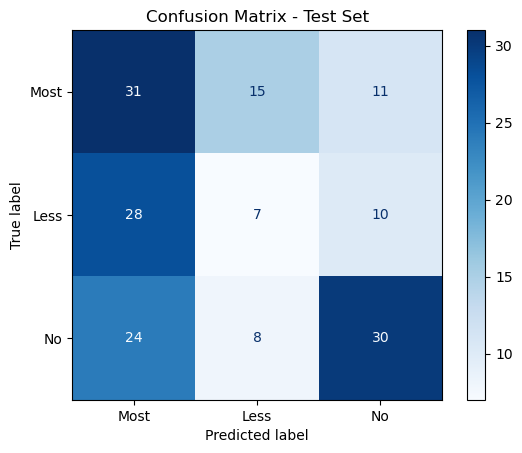

In [65]:
# === Class Distribution ===
print("=== Class Distribution ===")
print("Train set:")
print(y_train.value_counts())
print("\nTest set:")
print(y_test.value_counts())

# Make sure both are strings
y_test_str = y_test.astype(str)
test_pred_str = pd.Series(test_pred).map({0: 'Most', 1: 'Less', 2: 'No'}).astype(str)

# Confusion matrix
cm = confusion_matrix(y_test_str, test_pred_str, labels=['Most', 'Less', 'No'])

print("=== Confusion Matrix ===")
print(cm)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(cm, display_labels=['Most', 'Less', 'No'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Test Set")
plt.show()

In [69]:
label_map = {'Most': 0, 'Less': 1, 'No': 2}
y_num      = y.map(label_map).values
y_test_num = y_test.map(label_map).values

full_pred_num = final_model.predict(X)      # already 0/1/2
test_pred_num = final_model.predict(X_test) # already 0/1/2

cm_full = confusion_matrix(y_num,      full_pred_num, labels=[0,1,2])
cm_test = confusion_matrix(y_test_num, test_pred_num, labels=[0,1,2])

# Plot
disp = ConfusionMatrixDisplay(cm_full, display_labels=['Most','Less','No'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - WHOLE DATASET")
plt.show()

disp2 = ConfusionMatrixDisplay(cm_test, display_labels=['Most','Less','No'])
disp2.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - TEST SET ONLY")
plt.show()

TypeError: '>=' not supported between instances of 'str' and 'int'

In [170]:
# Try with XGBoost

# Convert labels to numbers
label_map = {'Most': 0, 'Less': 1, 'No': 2}
y_train_num = y_train.map(label_map)
y_test_num  = y_test.map(label_map)

# XGBoost training
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

best_xgb = None
best_score = -np.inf

print("Training XGBoost with nested CV")

for train_idx, val_idx in outer_cv.split(X_train, y_train_num):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train_num.iloc[train_idx]
    y_val = y_train_num.iloc[val_idx]
    
    xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')
    
    search = RandomizedSearchCV(
        xgb, param_grid, n_iter=20, cv=inner_cv,
        scoring='balanced_accuracy', n_jobs=1, random_state=42
    )
    search.fit(X_tr, y_tr)
    
    if search.best_score_ > best_score:
        best_score = search.best_score_
        best_xgb = search.best_estimator_

print(f"Best XGBoost CV balanced accuracy: {best_score:.4f}")

# Final model
final_xgb = best_xgb.fit(X_train, y_train_num)

# Test evaluation
test_pred_xgb = final_xgb.predict(X_test)

print("\n=== XGBoost TEST RESULTS ===")
print(f"Balanced Accuracy : {balanced_accuracy_score(y_test_num, test_pred_xgb):.4f}")
print(f"Macro F1-score    : {f1_score(y_test_num, test_pred_xgb, average='macro'):.4f}")
print(f"Accuracy          : {accuracy_score(y_test_num, test_pred_xgb):.4f}")

Training XGBoost with nested CV... (this may take a few minutes)
Best XGBoost CV balanced accuracy: 0.5413

=== XGBoost TEST RESULTS ===
Balanced Accuracy : 0.4724
Macro F1-score    : 0.4474
Accuracy          : 0.4695


<Figure size 700x600 with 0 Axes>

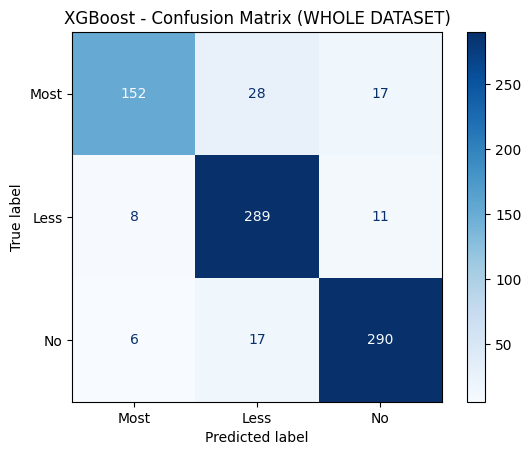

<Figure size 700x600 with 0 Axes>

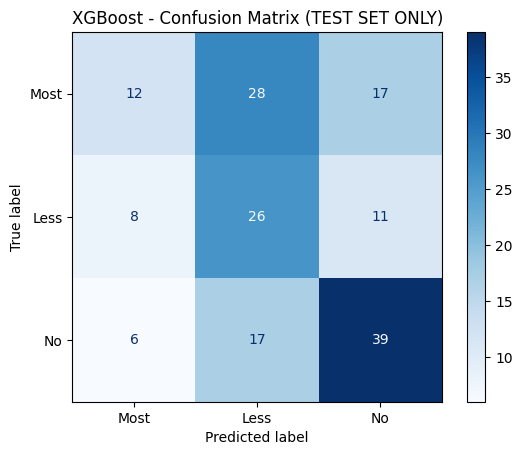

In [ ]:
# Plot from XGBoost

# Convert labels to numbers for consistency
label_map = {'Most': 0, 'Less': 1, 'No': 2}
y_num       = y.map(label_map).values
y_test_num  = y_test.map(label_map).values

# Get XGBoost predictions (returns numbers 0/1/2)
full_pred_xgb  = final_xgb.predict(X)
test_pred_xgb  = final_xgb.predict(X_test)

# Whole dataset confusion matrix
cm_full = confusion_matrix(y_num, full_pred_xgb, labels=[0, 1, 2])

plt.figure(figsize=(7,6))
disp = ConfusionMatrixDisplay(cm_full, display_labels=['Most', 'Less', 'No'])
disp.plot(cmap='Blues', values_format='d')
plt.title("XGBoost - Confusion Matrix (WHOLE DATASET)")
plt.show()

# Test set only confusion matrix
cm_test = confusion_matrix(y_test_num, test_pred_xgb, labels=[0, 1, 2])

plt.figure(figsize=(7,6))
disp2 = ConfusionMatrixDisplay(cm_test, display_labels=['Most', 'Less', 'No'])
disp2.plot(cmap='Blues', values_format='d')
plt.title("XGBoost - Confusion Matrix (TEST SET ONLY)")
plt.show()